Available cell data fields:
['cellID', 'refineflag', 'pVap', 'alpha.metal', 'condition', 'Laser_boundary', 'epsilon1', 'p_rgh', 'meltHistory', 'rayQ', 'meltTrackID', 'Deposition', 'T', 'gradT', 'U']
x_plane = 1.180769235361e-03 m = 1180.769 um
slice shape: (1184, 8)


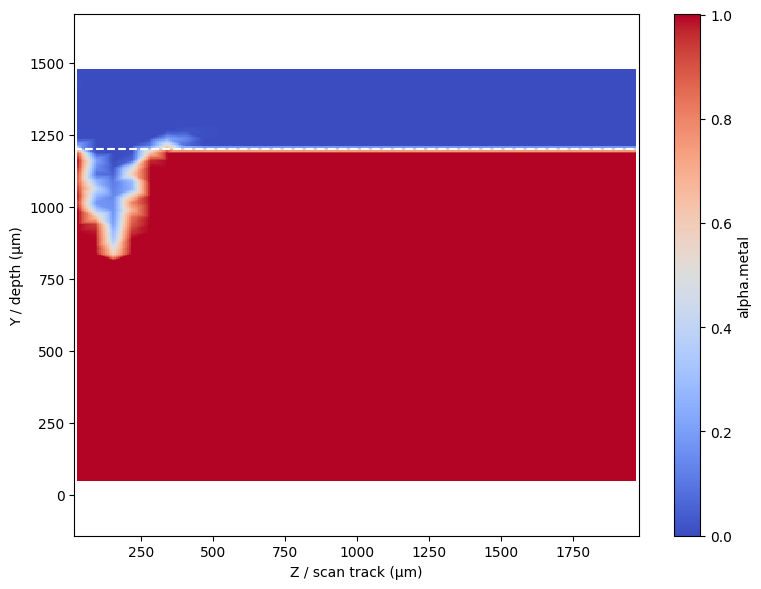

In [9]:
import numpy as np
import pandas as pd
import pyvista as pv
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# optional for notebook
%matplotlib inline


# -----------------------------
# SETTINGS
# -----------------------------
path = "/home/kanak/ISW_CFD_CA/tutorials/Connor_316L_base/VTK/Connor_316L_base_0.0009003816413.vtk"

FIELD_TO_PLOT = "alpha.metal"   # or "T"
INTERP_METHOD = "linear"        # use "nearest" for binary alpha.metal
NZ = 300
NY = 300


# -----------------------------
# READ MESH
# -----------------------------
mesh = pv.read(path)

print("Available cell data fields:")
print(mesh.cell_data.keys())

centers = mesh.cell_centers()
xyz = centers.points

df = pd.DataFrame({
    "x": xyz[:, 0],
    "y": xyz[:, 1],
    "z": xyz[:, 2],
    "alpha.metal": mesh.cell_data["alpha.metal"],
    "T": mesh.cell_data["T"],
})


# -----------------------------
# CONVERT TO MICRONS
# -----------------------------
df["x_um"] = df["x"] * 1e6
df["y_um"] = np.abs(df["y"]) * 1e6
df["z_um"] = df["z"] * 1e6


# -----------------------------
# YZ SLICE AT MID X
# -----------------------------
x_mid = 0.5 * (df["x"].min() + df["x"].max())
x_plane = df.loc[(df["x"] - x_mid).abs().idxmin(), "x"]

yz = df[np.isclose(df["x"], x_plane)].copy()

print(f"x_plane = {x_plane:.12e} m = {x_plane * 1e6:.3f} um")
print("slice shape:", yz.shape)


# -----------------------------
# INTERPOLATE
# -----------------------------
points = yz[["z_um", "y_um"]].to_numpy()
values = yz[FIELD_TO_PLOT].to_numpy()

zg = np.linspace(yz["z_um"].min(), yz["z_um"].max(), NZ)
yg = np.linspace(yz["y_um"].min(), yz["y_um"].max(), NY)

Zg, Yg = np.meshgrid(zg, yg)

Vg = griddata(points, values, (Zg, Yg), method=INTERP_METHOD)

# fill empty regions
if np.isnan(Vg).any():
    Vg_nearest = griddata(points, values, (Zg, Yg), method="nearest")
    Vg[np.isnan(Vg)] = Vg_nearest[np.isnan(Vg)]


# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8, 6))

pcm = plt.pcolormesh(Zg, Yg, Vg, shading="auto", cmap="coolwarm")

plt.xlabel("Z / scan track (µm)")
plt.ylabel("Y / depth (µm)")
plt.colorbar(pcm, label=FIELD_TO_PLOT)
plt.axhline(y=1200, linestyle="--", linewidth=1.5, color="white")
# plt.gca().invert_yaxis()
plt.axis("equal")
plt.tight_layout()
plt.show()